# Notebook 02 — Preprocess HC3 and Create Train/Val/Test Split

**Project:** MSc AI Dissertation — AI-Generated Text Detection  
**Student:** Abdul Hannaan Mohammed | B00409227 | UWS  
**Week:** 1–2 of 13  

**Goal of this notebook:**
- Load the flattened HC3 CSV from Notebook 01
- Clean and filter the text (remove empty, too-short, duplicate samples)
- Apply a stratified 70% train / 15% validation / 15% test split
- Save three CSVs: `train.csv`, `val.csv`, `test.csv` to `data/processed/`
- Print and save a split statistics table for the dissertation

## 1. Imports and Paths

In [1]:
import os
import json
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 150
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted')

# Stratified splitting utility from scikit-learn
from sklearn.model_selection import train_test_split

# ── Paths ──────────────────────────────────────────────────────────────────────
NOTEBOOK_DIR   = os.path.dirname(os.path.abspath('__file__'))
PROJECT_ROOT   = os.path.dirname(NOTEBOOK_DIR)
DATA_RAW       = os.path.join(PROJECT_ROOT, 'data', 'raw')
DATA_PROCESSED = os.path.join(PROJECT_ROOT, 'data', 'processed')
RESULTS_FIGS   = os.path.join(PROJECT_ROOT, 'results', 'figures')
RESULTS_TABLES = os.path.join(PROJECT_ROOT, 'results', 'tables')

for path in [DATA_PROCESSED, RESULTS_FIGS, RESULTS_TABLES]:
    os.makedirs(path, exist_ok=True)

print('Libraries loaded.')
print(f'Project root: {PROJECT_ROOT}')

Libraries loaded.
Project root: c:\Users\Abdul\OneDrive\Documents\Uni\MSc\term3\MSc-AI-Detection


## 2. Load HC3 Full Dataset

In [2]:
# Load the CSV saved by Notebook 01
csv_path = os.path.join(DATA_RAW, 'hc3_full.csv')
df = pd.read_csv(csv_path)

print(f'Loaded: {csv_path}')
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
print(f'\nLabel distribution:')
print(df['label'].value_counts().rename({0: 'human', 1: 'ai'}))
df.head(3)

Loaded: c:\Users\Abdul\OneDrive\Documents\Uni\MSc\term3\MSc-AI-Detection\data\raw\hc3_full.csv
Shape: (85431, 6)
Columns: ['question', 'text', 'label', 'label_name', 'source', 'word_count']

Label distribution:
label
human    58546
ai       26885
Name: count, dtype: int64


,question,text,label,label_name,source,word_count
0,"Why is every book I hear about a "" NY Times # ...","Basically there are many categories of "" Best ...",0,human,reddit_eli5,134
1,"Why is every book I hear about a "" NY Times # ...","If you 're hearing about it , it 's because it...",0,human,reddit_eli5,73
2,"Why is every book I hear about a "" NY Times # ...","One reason is lots of catagories . However , h...",0,human,reddit_eli5,62


## 3. Text Cleaning

We apply minimal cleaning — RoBERTa's tokeniser handles most normalisation internally.  
We only remove samples that would be genuinely unusable:
- Null / empty text
- Fewer than 10 words (too short to classify meaningfully)
- Exact duplicates (same text appearing twice)

> **DISSERTATION NOTE:** Explain this in Chapter 3 (Methodology) under *Data Preprocessing*.

In [3]:
original_count = len(df)

# Step 1 — Drop rows with null or empty text
df = df.dropna(subset=['text'])
df = df[df['text'].str.strip() != '']
after_null = len(df)

# Step 2 — Recompute word count (in case it wasn't saved)
df['word_count'] = df['text'].apply(lambda t: len(str(t).split()))

# Step 3 — Remove samples with fewer than 10 words
MIN_WORDS = 10
df = df[df['word_count'] >= MIN_WORDS]
after_short = len(df)

# Step 4 — Remove exact duplicate texts (keep first occurrence)
df = df.drop_duplicates(subset=['text'], keep='first')
after_dedup = len(df)

# Reset index after filtering
df = df.reset_index(drop=True)

print('=== Cleaning Report ===')
print(f'  Original samples      : {original_count:,}')
print(f'  After removing nulls  : {after_null:,}  (removed {original_count - after_null})')
print(f'  After min-word filter : {after_short:,}  (removed {after_null - after_short})')
print(f'  After deduplication   : {after_dedup:,}  (removed {after_short - after_dedup})')
print(f'  Total removed         : {original_count - after_dedup}')
print(f'  Final dataset size    : {after_dedup:,}')
print(f'\nLabel distribution after cleaning:')
print(df['label_name'].value_counts())

=== Cleaning Report ===
  Original samples      : 85,431
  After removing nulls  : 85,431  (removed 0)
  After min-word filter : 84,792  (removed 639)
  After deduplication   : 78,795  (removed 5997)
  Total removed         : 6636
  Final dataset size    : 78,795

Label distribution after cleaning:
label_name
human    52584
ai       26211
Name: count, dtype: int64


## 4. Truncate Text to 512 Tokens (RoBERTa Limit)

RoBERTa has a maximum input length of 512 tokens. Very long texts will be truncated automatically by the tokeniser during training, but we truncate here at the **word** level (approx 400 words ≈ 512 tokens) so the CSVs reflect what the model actually sees.

We keep the full text in a separate column for reference.

In [4]:
MAX_WORDS = 400  # conservative word limit — ~512 tokens for RoBERTa

# Keep the original text for reference
df['text_full'] = df['text']

# Truncate long texts to first MAX_WORDS words
df['text'] = df['text'].apply(
    lambda t: ' '.join(str(t).split()[:MAX_WORDS])
)

# Update word count after truncation
df['word_count'] = df['text'].apply(lambda t: len(t.split()))

n_truncated = (df['word_count'] == MAX_WORDS).sum()
print(f'Samples truncated to {MAX_WORDS} words: {n_truncated:,} ({n_truncated/len(df)*100:.1f}%)')
print(f'\nWord count stats after truncation:')
print(df['word_count'].describe().round(1))

Samples truncated to 400 words: 3,014 (3.8%)

Word count stats after truncation:
count    78795.0
mean       139.8
std         97.5
min         10.0
25%         60.0
50%        122.0
75%        196.0
max        400.0
Name: word_count, dtype: float64


## 5. Stratified Train / Validation / Test Split

We use a **stratified** split so that the class ratio (human vs AI) is preserved in all three sets.

| Split | Proportion | Purpose |
|-------|-----------|--------|
| Train | 70% | Fine-tune RoBERTa |
| Validation | 15% | Monitor training, tune hyperparameters |
| Test | 15% | Final held-out evaluation (never seen during training) |

> **DISSERTATION NOTE:** This split strategy is described in Chapter 3 (Methodology) under *Experimental Setup*.

In [5]:
RANDOM_SEED = 42  # fixed seed for reproducibility — report this in dissertation

# Step 1: split off 70% train, 30% temp
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,          # 30% goes to temp (will be split into val + test)
    stratify=df['label'],    # preserve class balance
    random_state=RANDOM_SEED
)

# Step 2: split the 30% temp into 50/50 → 15% val + 15% test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df['label'],
    random_state=RANDOM_SEED
)

# Reset indices
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

total = len(df)
print('=== Train / Validation / Test Split ===')
print(f'  Total samples : {total:,}')
print(f'  Train         : {len(train_df):,}  ({len(train_df)/total*100:.1f}%)')
print(f'  Validation    : {len(val_df):,}   ({len(val_df)/total*100:.1f}%)')
print(f'  Test          : {len(test_df):,}   ({len(test_df)/total*100:.1f}%)')

print('\n--- Class balance per split ---')
for name, split in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    counts = split['label_name'].value_counts()
    total_split = len(split)
    print(f'  {name:6s}: human={counts.get("human",0):,} ({counts.get("human",0)/total_split*100:.1f}%)  '
          f'ai={counts.get("ai",0):,} ({counts.get("ai",0)/total_split*100:.1f}%)')

=== Train / Validation / Test Split ===
  Total samples : 78,795
  Train         : 55,156  (70.0%)
  Validation    : 11,819   (15.0%)
  Test          : 11,820   (15.0%)

--- Class balance per split ---
  Train : human=36,808 (66.7%)  ai=18,348 (33.3%)
  Val   : human=7,888 (66.7%)  ai=3,931 (33.3%)
  Test  : human=7,888 (66.7%)  ai=3,932 (33.3%)


## 6. Save Split CSVs to `data/processed/`

> **SCREENSHOT REMINDER:** After this cell runs, take a screenshot of the output.  
> Save as: `screenshots/05_train_val_test_split.png`

In [6]:
# Columns to keep in the processed CSVs
# text_full is dropped — the model only sees the truncated text
cols_to_save = ['text', 'label', 'label_name', 'source', 'word_count']

train_path = os.path.join(DATA_PROCESSED, 'train.csv')
val_path   = os.path.join(DATA_PROCESSED, 'val.csv')
test_path  = os.path.join(DATA_PROCESSED, 'test.csv')

train_df[cols_to_save].to_csv(train_path, index=False, encoding='utf-8')
val_df[cols_to_save].to_csv(val_path,     index=False, encoding='utf-8')
test_df[cols_to_save].to_csv(test_path,   index=False, encoding='utf-8')

print(f'Saved: {train_path}  ({len(train_df):,} rows)')
print(f'Saved: {val_path}    ({len(val_df):,} rows)')
print(f'Saved: {test_path}   ({len(test_df):,} rows)')

Saved: c:\Users\Abdul\OneDrive\Documents\Uni\MSc\term3\MSc-AI-Detection\data\processed\train.csv  (55,156 rows)
Saved: c:\Users\Abdul\OneDrive\Documents\Uni\MSc\term3\MSc-AI-Detection\data\processed\val.csv    (11,819 rows)
Saved: c:\Users\Abdul\OneDrive\Documents\Uni\MSc\term3\MSc-AI-Detection\data\processed\test.csv   (11,820 rows)


## 7. Split Statistics Table (for Dissertation)

> **DISSERTATION NOTE:** This becomes **Table 2** in Chapter 3 (Methodology) — Dataset Split Statistics.

In [7]:
# Build a clean split statistics table
split_stats = []
for split_name, split_df in [('Train (70%)', train_df), ('Validation (15%)', val_df), ('Test (15%)', test_df)]:
    n_human = (split_df['label'] == 0).sum()
    n_ai    = (split_df['label'] == 1).sum()
    split_stats.append({
        'Split':            split_name,
        'Total Samples':    len(split_df),
        'Human Samples':    int(n_human),
        'AI Samples':       int(n_ai),
        '% Human':          f'{n_human/len(split_df)*100:.1f}%',
        '% AI':             f'{n_ai/len(split_df)*100:.1f}%',
        'Avg Word Count':   round(split_df['word_count'].mean(), 1),
    })

stats_df = pd.DataFrame(split_stats)

table_path = os.path.join(RESULTS_TABLES, 'table02_split_statistics.csv')
stats_df.to_csv(table_path, index=False, encoding='utf-8')

print('=== TABLE 2: Dataset Split Statistics (for dissertation) ===')
print(stats_df.to_string(index=False))
print(f'\nSaved to: {table_path}')

=== TABLE 2: Dataset Split Statistics (for dissertation) ===
           Split  Total Samples  Human Samples  AI Samples % Human  % AI  Avg Word Count
     Train (70%)          55156          36808       18348   66.7% 33.3%           139.6
Validation (15%)          11819           7888        3931   66.7% 33.3%           140.7
      Test (15%)          11820           7888        3932   66.7% 33.3%           139.6

Saved to: c:\Users\Abdul\OneDrive\Documents\Uni\MSc\term3\MSc-AI-Detection\results\tables\table02_split_statistics.csv


## 8. Visualise the Split

Figure saved: c:\Users\Abdul\OneDrive\Documents\Uni\MSc\term3\MSc-AI-Detection\results\figures\fig04_train_val_test_split.png


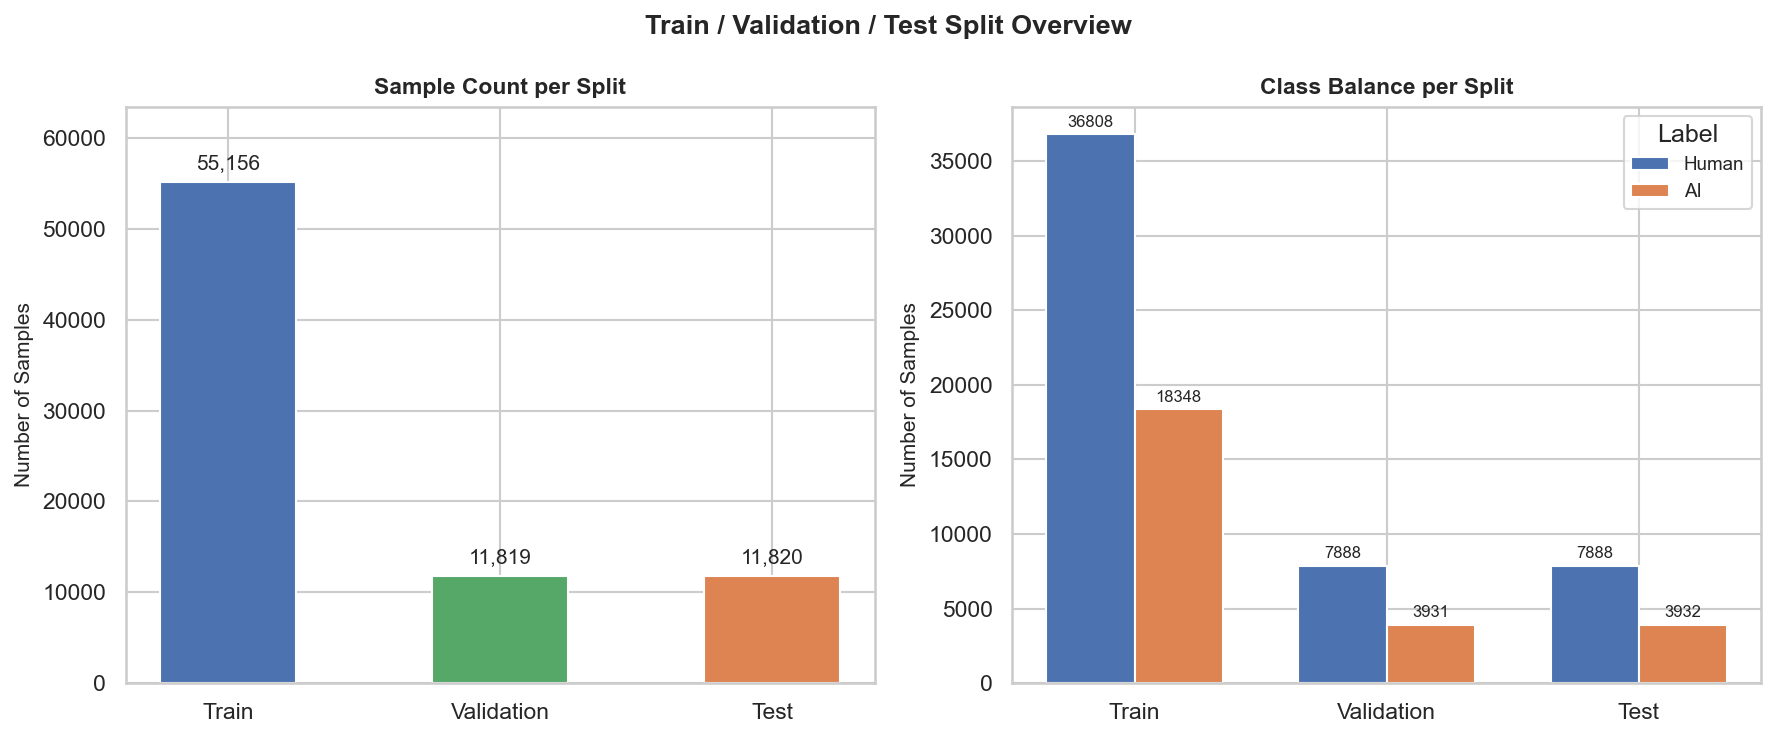

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Train / Validation / Test Split Overview', fontsize=13, fontweight='bold')

# Plot 1 — Split sizes
split_names  = ['Train', 'Validation', 'Test']
split_sizes  = [len(train_df), len(val_df), len(test_df)]
split_colors = ['#4C72B0', '#55A868', '#DD8452']

bars = axes[0].bar(split_names, split_sizes, color=split_colors, edgecolor='white', width=0.5)
axes[0].set_title('Sample Count per Split', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Number of Samples', fontsize=10)
axes[0].bar_label(bars, labels=[f'{s:,}' for s in split_sizes], padding=4, fontsize=10)
axes[0].set_ylim(0, max(split_sizes) * 1.15)

# Plot 2 — Class balance per split (grouped bar)
x = np.arange(3)
width = 0.35
human_counts = [(train_df['label']==0).sum(), (val_df['label']==0).sum(), (test_df['label']==0).sum()]
ai_counts    = [(train_df['label']==1).sum(), (val_df['label']==1).sum(), (test_df['label']==1).sum()]

b1 = axes[1].bar(x - width/2, human_counts, width, label='Human', color='#4C72B0', edgecolor='white')
b2 = axes[1].bar(x + width/2, ai_counts,    width, label='AI',    color='#DD8452', edgecolor='white')
axes[1].set_title('Class Balance per Split', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Number of Samples', fontsize=10)
axes[1].set_xticks(x)
axes[1].set_xticklabels(split_names)
axes[1].legend(title='Label', fontsize=9)
axes[1].bar_label(b1, fontsize=8, padding=2)
axes[1].bar_label(b2, fontsize=8, padding=2)

plt.tight_layout()

fig_path = os.path.join(RESULTS_FIGS, 'fig04_train_val_test_split.png')
plt.savefig(fig_path, bbox_inches='tight', dpi=150)
print(f'Figure saved: {fig_path}')
plt.show()

## 9. Save Preprocessing Metadata

In [9]:
# Save key numbers so Notebook 03 can read them
preprocess_meta = {
    'original_samples':   original_count,
    'final_samples':      len(df),
    'removed_samples':    original_count - len(df),
    'min_word_filter':    MIN_WORDS,
    'max_word_truncation': MAX_WORDS,
    'random_seed':        RANDOM_SEED,
    'train_size':         len(train_df),
    'val_size':           len(val_df),
    'test_size':          len(test_df),
    'train_human':        int((train_df['label']==0).sum()),
    'train_ai':           int((train_df['label']==1).sum()),
    'val_human':          int((val_df['label']==0).sum()),
    'val_ai':             int((val_df['label']==1).sum()),
    'test_human':         int((test_df['label']==0).sum()),
    'test_ai':            int((test_df['label']==1).sum()),
    'files': {
        'train': train_path,
        'val':   val_path,
        'test':  test_path
    }
}

meta_path = os.path.join(DATA_PROCESSED, 'preprocessing_metadata.json')
with open(meta_path, 'w') as f:
    json.dump(preprocess_meta, f, indent=2)

print('Preprocessing complete. Metadata saved.')
print(json.dumps(preprocess_meta, indent=2))

Preprocessing complete. Metadata saved.
{
  "original_samples": 85431,
  "final_samples": 78795,
  "removed_samples": 6636,
  "min_word_filter": 10,
  "max_word_truncation": 400,
  "random_seed": 42,
  "train_size": 55156,
  "val_size": 11819,
  "test_size": 11820,
  "train_human": 36808,
  "train_ai": 18348,
  "val_human": 7888,
  "val_ai": 3931,
  "test_human": 7888,
  "test_ai": 3932,
  "files": {
    "train": "c:\\Users\\Abdul\\OneDrive\\Documents\\Uni\\MSc\\term3\\MSc-AI-Detection\\data\\processed\\train.csv",
    "val": "c:\\Users\\Abdul\\OneDrive\\Documents\\Uni\\MSc\\term3\\MSc-AI-Detection\\data\\processed\\val.csv",
    "test": "c:\\Users\\Abdul\\OneDrive\\Documents\\Uni\\MSc\\term3\\MSc-AI-Detection\\data\\processed\\test.csv"
  }
}


## 10. Notebook Summary

### What was done
1. Loaded `hc3_full.csv` from `data/raw/`
2. Removed null, too-short (< 10 words), and duplicate samples
3. Truncated long texts to 400 words (≈ 512 RoBERTa tokens)
4. Applied stratified 70/15/15 train/val/test split (seed=42)
5. Saved `train.csv`, `val.csv`, `test.csv` to `data/processed/`
6. Saved split statistics table (dissertation Table 2)
7. Saved split visualisation figure (dissertation Figure 4)

### Files produced
| File | Location | Purpose |
|------|----------|---------|
| `train.csv` | `data/processed/` | RoBERTa training data |
| `val.csv` | `data/processed/` | Validation during training |
| `test.csv` | `data/processed/` | Final held-out evaluation |
| `preprocessing_metadata.json` | `data/processed/` | Key stats for Notebook 03 |
| `table02_split_statistics.csv` | `results/tables/` | Dissertation Table 2 |
| `fig04_train_val_test_split.png` | `results/figures/` | Dissertation Figure 4 |

### Next step
**Notebook 03:** `03_train_roberta.ipynb` — Fine-tune RoBERTa-base on `train.csv`, track with Weights & Biases, save best model checkpoint.